# 🏠 Análisis de Precios de Airbnb

Este notebook realiza un análisis exploratorio completo sobre una base de datos de listings de Airbnb en ciudades de Estados Unidos (NYC, LA, SF, Chicago, DC y Boston).

El objetivo es entender la distribución de las variables, identificar cuáles tienen mayor influencia sobre el precio, y detectar patrones relevantes para un modelo predictivo.

---
## Parte 1 — Carga de datos e importación de librerías

Importamos las librerías estándar para análisis de datos y visualización. `pandas` y `numpy` para manipulación numérica, `matplotlib` y `seaborn` para gráficos, y `warnings` para suprimir mensajes innecesarios.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


Cargamos el dataset. Se usa `on_bad_lines='skip'` porque el campo `amenities` contiene comas internas que rompen algunas filas, y `low_memory=False` para evitar inferencia de tipos incorrecta.

In [2]:
df = pd.read_csv('Base_de_datos_Proyecto.csv', on_bad_lines='skip', low_memory=False)

print(f'Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')
df.head(3)

Filas: 64,056  |  Columnas: 29


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696523629970756,-73.99161684624262,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115415949685,-73.98903992265213,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.80810998936211,-73.94375584395794,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0


---
## Parte 2 — Análisis Exploratorio de Datos (EDA)

### 2.1 Limpieza y preparación

Antes de calcular estadísticas, convertimos las columnas numéricas que se importaron como texto y recuperamos el precio real a partir de `log_price` (que está en escala logarítmica natural).

In [3]:
# Conversión de columnas numéricas
numeric_cols = ['bathrooms', 'bedrooms', 'beds', 'number_of_reviews',
                'review_scores_rating', 'latitude', 'longitude', 'accommodates']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Recuperar precio original (en dólares)
df['price'] = np.exp(df['log_price'])

# Convertir fechas
df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
df['first_review'] = pd.to_datetime(df['first_review'], errors='coerce')

print('Tipos de datos tras conversión:')
print(df[numeric_cols + ['price']].dtypes)

Tipos de datos tras conversión:
bathrooms               float64
bedrooms                float64
beds                    float64
number_of_reviews       float64
review_scores_rating    float64
latitude                float64
longitude               float64
accommodates              int64
price                   float64
dtype: object


### 2.2 Valores nulos

Revisamos el porcentaje de valores faltantes por columna. Las variables con más del 20% de nulos requieren atención especial en la etapa de modelado.

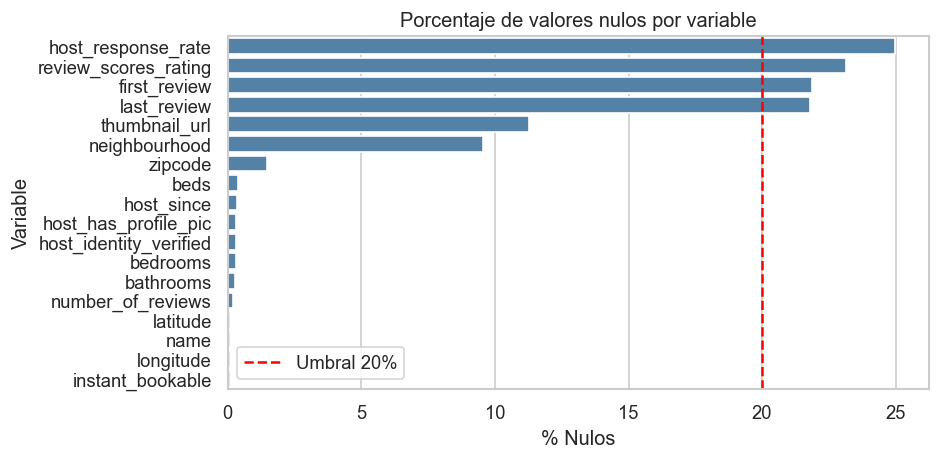

              Variable  % Nulos
    host_response_rate    24.99
  review_scores_rating    23.13
          first_review    21.87
           last_review    21.81
         thumbnail_url    11.28
         neighbourhood     9.57
               zipcode     1.48
                  beds     0.37
            host_since     0.33
  host_has_profile_pic     0.32
host_identity_verified     0.32
              bedrooms     0.31
             bathrooms     0.26
     number_of_reviews     0.18
              latitude     0.08
                  name     0.08
             longitude     0.08
      instant_bookable     0.07


In [4]:
nulls = df.isnull().mean().sort_values(ascending=False) * 100
nulls_df = nulls[nulls > 0].reset_index()
nulls_df.columns = ['Variable', '% Nulos']
nulls_df['% Nulos'] = nulls_df['% Nulos'].round(2)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=nulls_df, x='% Nulos', y='Variable', ax=ax, color='steelblue')
ax.axvline(20, color='red', linestyle='--', label='Umbral 20%')
ax.set_title('Porcentaje de valores nulos por variable')
ax.legend()
plt.tight_layout()
plt.show()

print(nulls_df.to_string(index=False))

### 2.3 Estadísticas descriptivas

Calculamos las estadísticas principales (media, mediana, desviación estándar, cuartiles) para todas las variables numéricas. Esto nos da una primera idea de la escala y dispersión de cada variable.

In [5]:
desc_cols = ['price', 'log_price', 'accommodates', 'bathrooms',
             'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']

stats = df[desc_cols].describe().T
stats['median'] = df[desc_cols].median()
stats['skewness'] = df[desc_cols].skew()
stats = stats[['count', 'mean', 'median', 'std', 'min', '25%', '75%', 'max', 'skewness']]
stats = stats.round(3)

print(stats.to_string())

                        count     mean  median      std   min     25%     75%     max  skewness
price                 64056.0  160.221   110.0  168.393   1.0  74.000  185.00  1999.0     4.287
log_price             64056.0    4.781     4.7    0.718   0.0   4.304    5.22     7.6     0.509
accommodates          64056.0    3.139     2.0    2.141   1.0   2.000    4.00    16.0     2.244
bathrooms             63888.0    1.234     1.0    0.581   0.0   1.000    1.00     8.0     3.708
bedrooms              63860.0    1.261     1.0    0.848   0.0   1.000    1.00    10.0     1.988
beds                  63819.0    1.700     1.0    1.237   0.0   1.000    2.00    18.0     3.318
number_of_reviews     63943.0   20.495     5.0   37.320   0.0   1.000   23.00   542.0     3.720
review_scores_rating  49240.0   94.041    96.0    7.875  20.0  92.000  100.00   100.0    -3.372


**Observaciones clave:**
- `price` tiene una distribución muy sesgada a la derecha (skewness alto), por eso se trabaja con `log_price` que tiene una distribución mucho más simétrica.
- La mayoría de los alojamientos tienen 1-2 habitaciones y acomodan entre 2 y 4 personas.
- `review_scores_rating` se concentra en valores altos (cerca de 90-100), lo que indica sesgo positivo en las reseñas.

---
### 2.4 Distribución del precio

Comparamos la distribución del precio original vs. su transformación logarítmica. Esta transformación es fundamental para reducir el impacto de outliers extremos en el modelado.

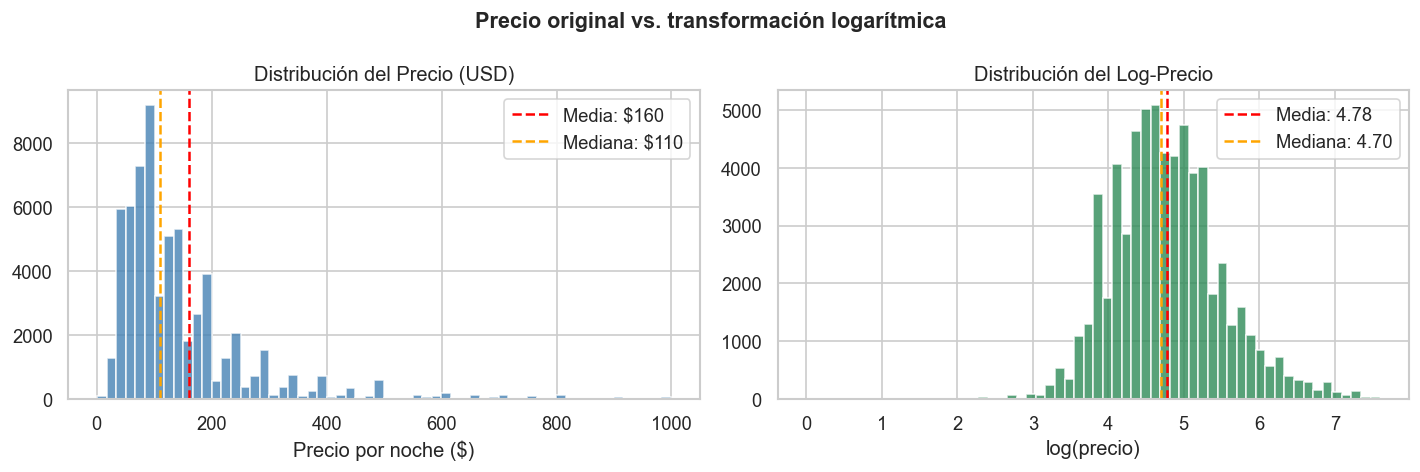

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Precio original (filtrado para mejor visualización)
price_filtered = df['price'][df['price'] < 1000]
axes[0].hist(price_filtered, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', label=f"Media: ${df['price'].mean():.0f}")
axes[0].axvline(df['price'].median(), color='orange', linestyle='--', label=f"Mediana: ${df['price'].median():.0f}")
axes[0].set_title('Distribución del Precio (USD)')
axes[0].set_xlabel('Precio por noche ($)')
axes[0].legend()

# Log-precio
axes[1].hist(df['log_price'], bins=60, color='seagreen', edgecolor='white', alpha=0.8)
axes[1].axvline(df['log_price'].mean(), color='red', linestyle='--', label=f"Media: {df['log_price'].mean():.2f}")
axes[1].axvline(df['log_price'].median(), color='orange', linestyle='--', label=f"Mediana: {df['log_price'].median():.2f}")
axes[1].set_title('Distribución del Log-Precio')
axes[1].set_xlabel('log(precio)')
axes[1].legend()

plt.suptitle('Precio original vs. transformación logarítmica', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 2.5 Precio por ciudad

Analizamos cómo varía el precio entre ciudades usando box plots. Esta visualización nos permite comparar medianas y detectar la dispersión y outliers por ciudad.

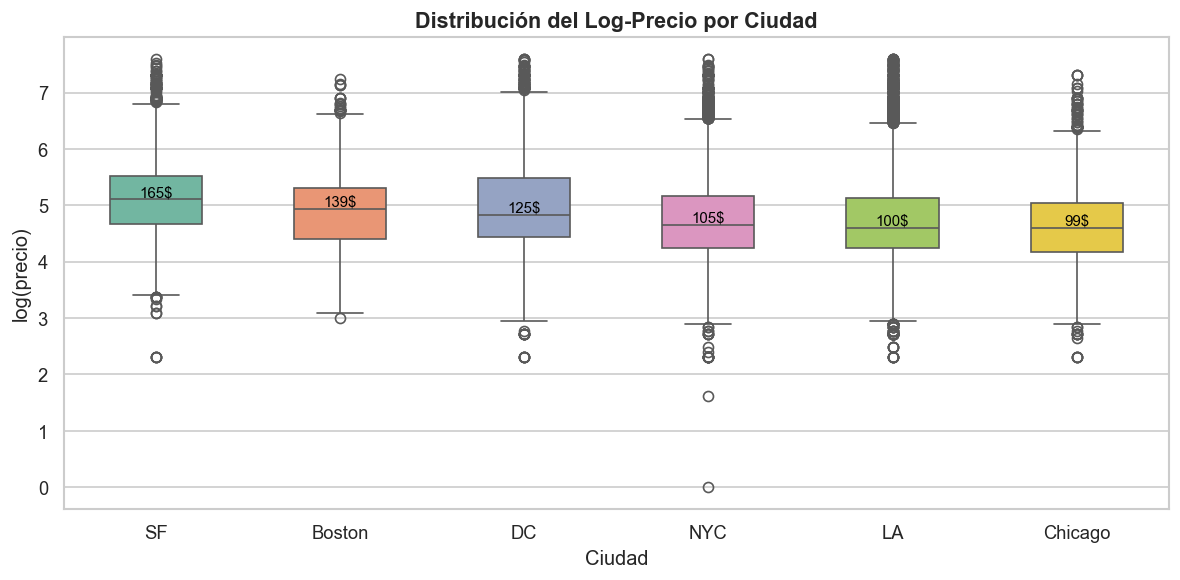

In [7]:
city_order = df.groupby('city')['log_price'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='city', y='log_price', order=city_order,
            palette='Set2', width=0.5, ax=ax)
ax.set_title('Distribución del Log-Precio por Ciudad', fontsize=13, fontweight='bold')
ax.set_xlabel('Ciudad')
ax.set_ylabel('log(precio)')

# Añadir mediana como texto
for i, city in enumerate(city_order):
    med = df[df['city'] == city]['log_price'].median()
    ax.text(i, med + 0.05, f'{np.exp(med):.0f}$', ha='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()

---
### 2.6 Precio por tipo de habitación

El `room_type` es una de las variables más intuitivamente relacionadas con el precio. Comparamos las tres categorías principales.

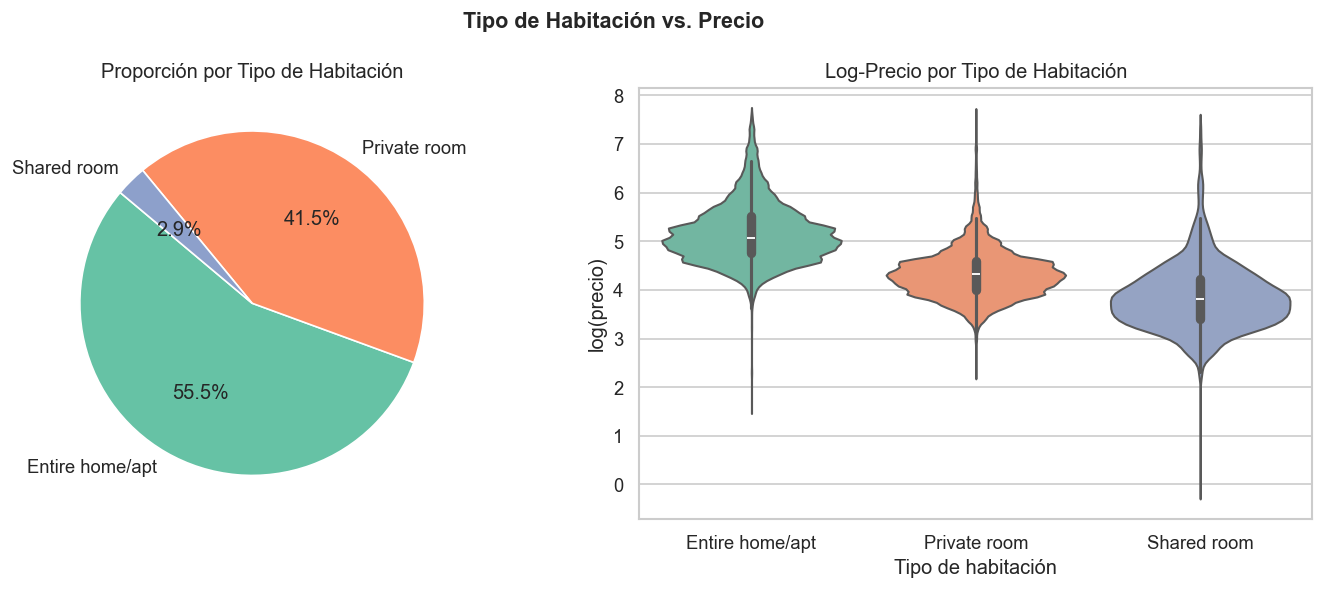

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Conteo de tipos
room_counts = df['room_type'].value_counts()
axes[0].pie(room_counts, labels=room_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2'), startangle=140)
axes[0].set_title('Proporción por Tipo de Habitación')

# Precio por tipo
room_order = df.groupby('room_type')['log_price'].median().sort_values(ascending=False).index
sns.violinplot(data=df, x='room_type', y='log_price', order=room_order,
               palette='Set2', ax=axes[1], inner='box')
axes[1].set_title('Log-Precio por Tipo de Habitación')
axes[1].set_xlabel('Tipo de habitación')
axes[1].set_ylabel('log(precio)')

plt.suptitle('Tipo de Habitación vs. Precio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 2.7 Variables numéricas vs. precio (scatter plots)

Exploramos la relación entre el precio y las variables numéricas más importantes: capacidad de huéspedes, habitaciones, baños y calificación. Se espera una correlación positiva con la mayoría de estas variables.

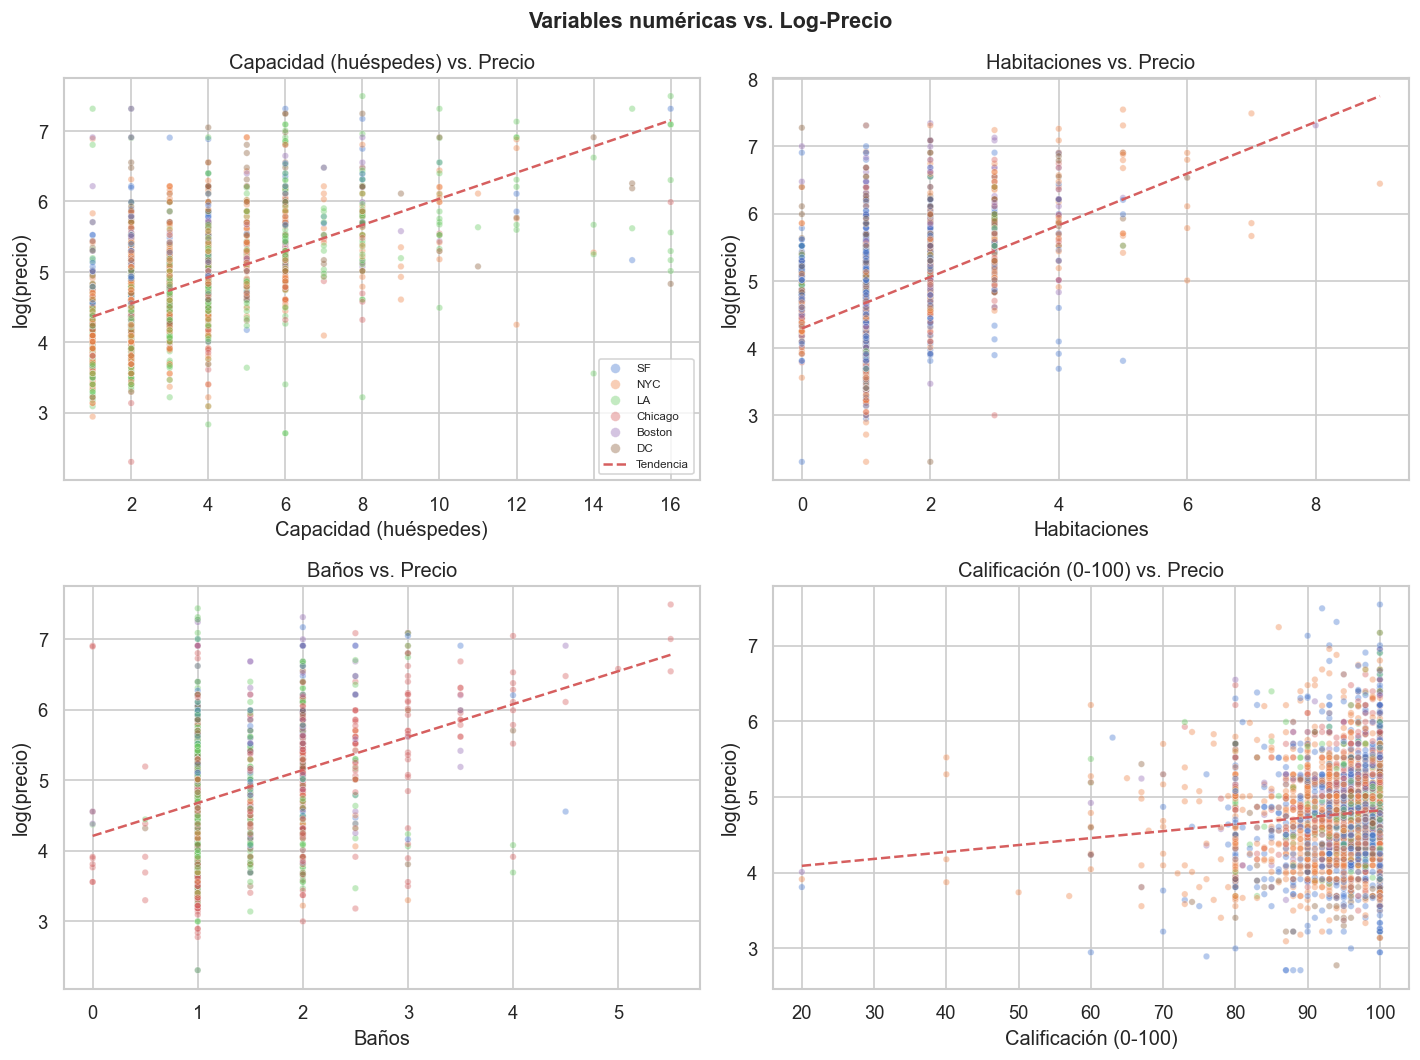

In [9]:
scatter_vars = ['accommodates', 'bedrooms', 'bathrooms', 'review_scores_rating']
labels = ['Capacidad (huéspedes)', 'Habitaciones', 'Baños', 'Calificación (0-100)']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, (var, label) in enumerate(zip(scatter_vars, labels)):
    sample = df[[var, 'log_price', 'city']].dropna().sample(n=min(3000, len(df)), random_state=42)
    sns.scatterplot(data=sample, x=var, y='log_price', hue='city',
                    alpha=0.4, s=15, ax=axes[i], legend=(i == 0))
    # Línea de tendencia
    z = np.polyfit(sample[var].dropna(), sample.loc[sample[var].notna(), 'log_price'], 1)
    p = np.poly1d(z)
    xline = np.linspace(sample[var].min(), sample[var].max(), 100)
    axes[i].plot(xline, p(xline), 'r--', linewidth=1.5, label='Tendencia')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('log(precio)')
    axes[i].set_title(f'{label} vs. Precio')
    if i == 0:
        axes[i].legend(fontsize=7, markerscale=1.5)

plt.suptitle('Variables numéricas vs. Log-Precio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 2.8 Mapa de calor de correlaciones

El mapa de calor muestra las correlaciones entre todas las variables numéricas. Valores cercanos a 1 o -1 indican relaciones fuertes. Nos interesa especialmente la fila/columna de `log_price`.

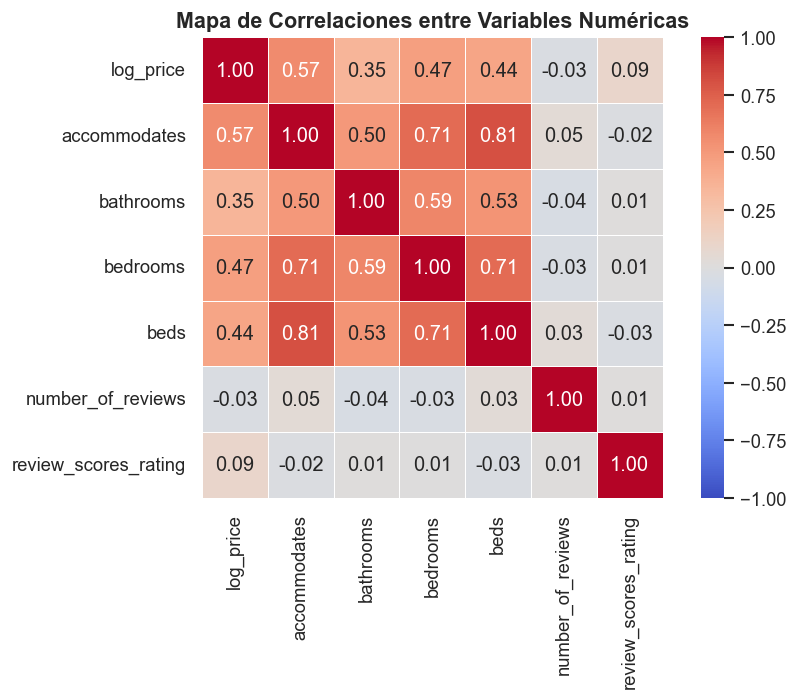


Correlación con log_price (de mayor a menor):
accommodates            0.570
bedrooms                0.469
beds                    0.444
bathrooms               0.351
review_scores_rating    0.094
number_of_reviews      -0.030
Name: log_price, dtype: float64


In [10]:
corr_cols = ['log_price', 'accommodates', 'bathrooms', 'bedrooms',
             'beds', 'number_of_reviews', 'review_scores_rating']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # solo triángulo inferior
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            mask=False, ax=ax, square=True)
ax.set_title('Mapa de Correlaciones entre Variables Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Ranking de correlación con el precio
print('\nCorrelación con log_price (de mayor a menor):')
print(corr_matrix['log_price'].drop('log_price').sort_values(ascending=False).round(3))

---
### 2.9 Precio por número de habitaciones

Analizamos cómo escala el precio conforme aumentan las habitaciones. Se espera una relación positiva clara, con mayor varianza en propiedades más grandes.

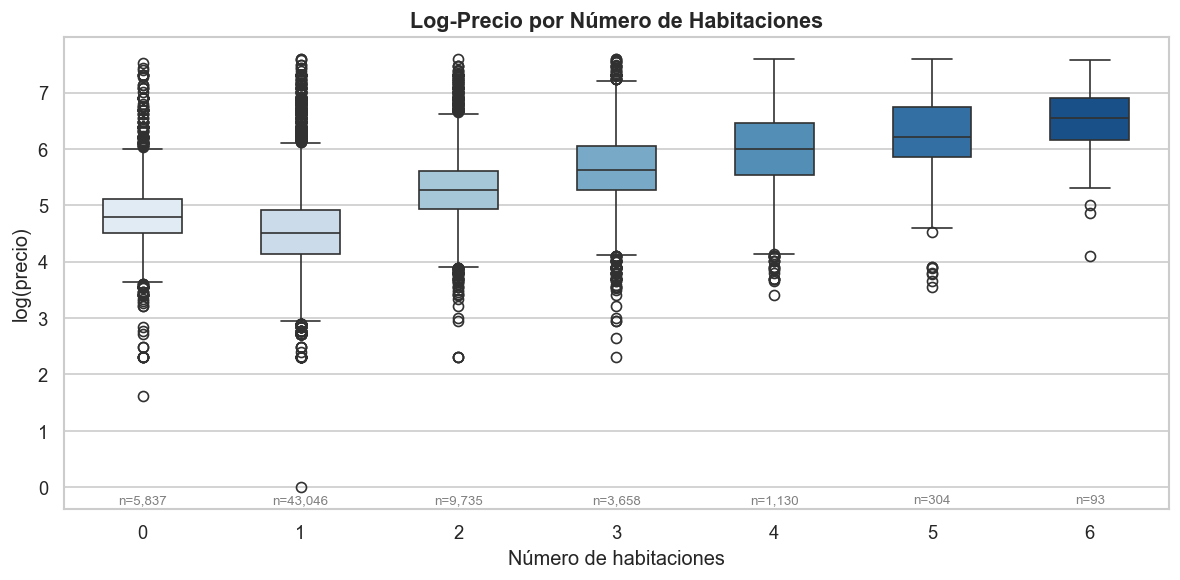

In [11]:
df_bed = df[df['bedrooms'].between(0, 6)].copy()
df_bed['bedrooms'] = df_bed['bedrooms'].astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_bed, x='bedrooms', y='log_price',
            palette='Blues', width=0.5, ax=ax)

# Conteo de listings por categoría
counts = df_bed['bedrooms'].value_counts().sort_index()
for i, (bed, count) in enumerate(counts.items()):
    ax.text(i, ax.get_ylim()[0] + 0.1, f'n={count:,}',
            ha='center', fontsize=8, color='gray')

ax.set_title('Log-Precio por Número de Habitaciones', fontsize=13, fontweight='bold')
ax.set_xlabel('Número de habitaciones')
ax.set_ylabel('log(precio)')
plt.tight_layout()
plt.show()

---
### 2.10 Política de cancelación y precio

Exploramos si la política de cancelación (flexible, moderada, estricta) está asociada con diferencias de precio, lo que podría reflejar el perfil del anfitrión o tipo de propiedad.

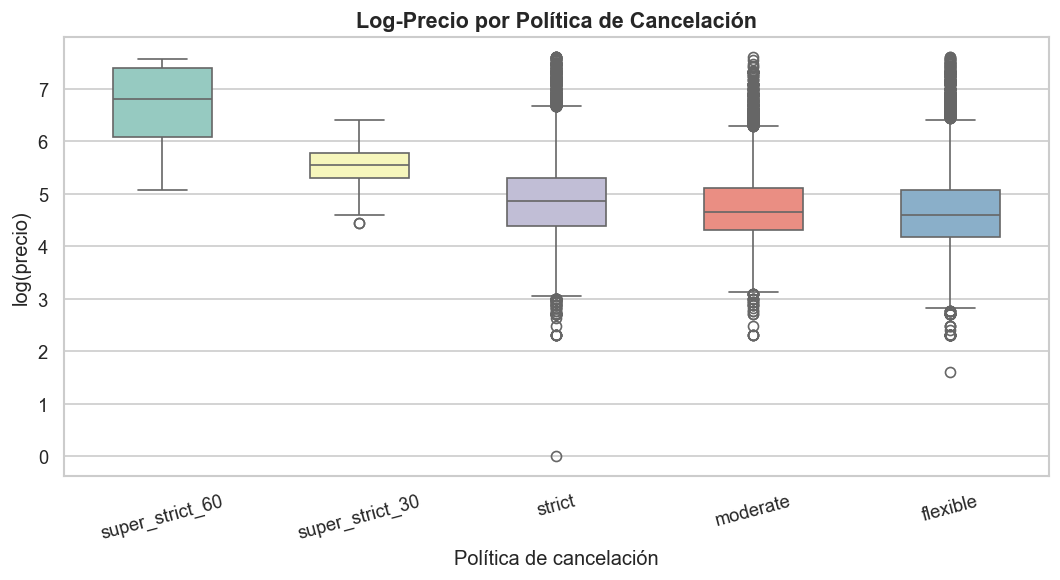

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
order = df.groupby('cancellation_policy')['log_price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='cancellation_policy', y='log_price',
            order=order, palette='Set3', width=0.5, ax=ax)
ax.set_title('Log-Precio por Política de Cancelación', fontsize=13, fontweight='bold')
ax.set_xlabel('Política de cancelación')
ax.set_ylabel('log(precio)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

---
### 2.11 Distribución geográfica del precio (mapa de puntos)

Graficamos la ubicación de cada listing con un color según su precio. Esto permite detectar zonas geográficas con mayor concentración de propiedades caras.

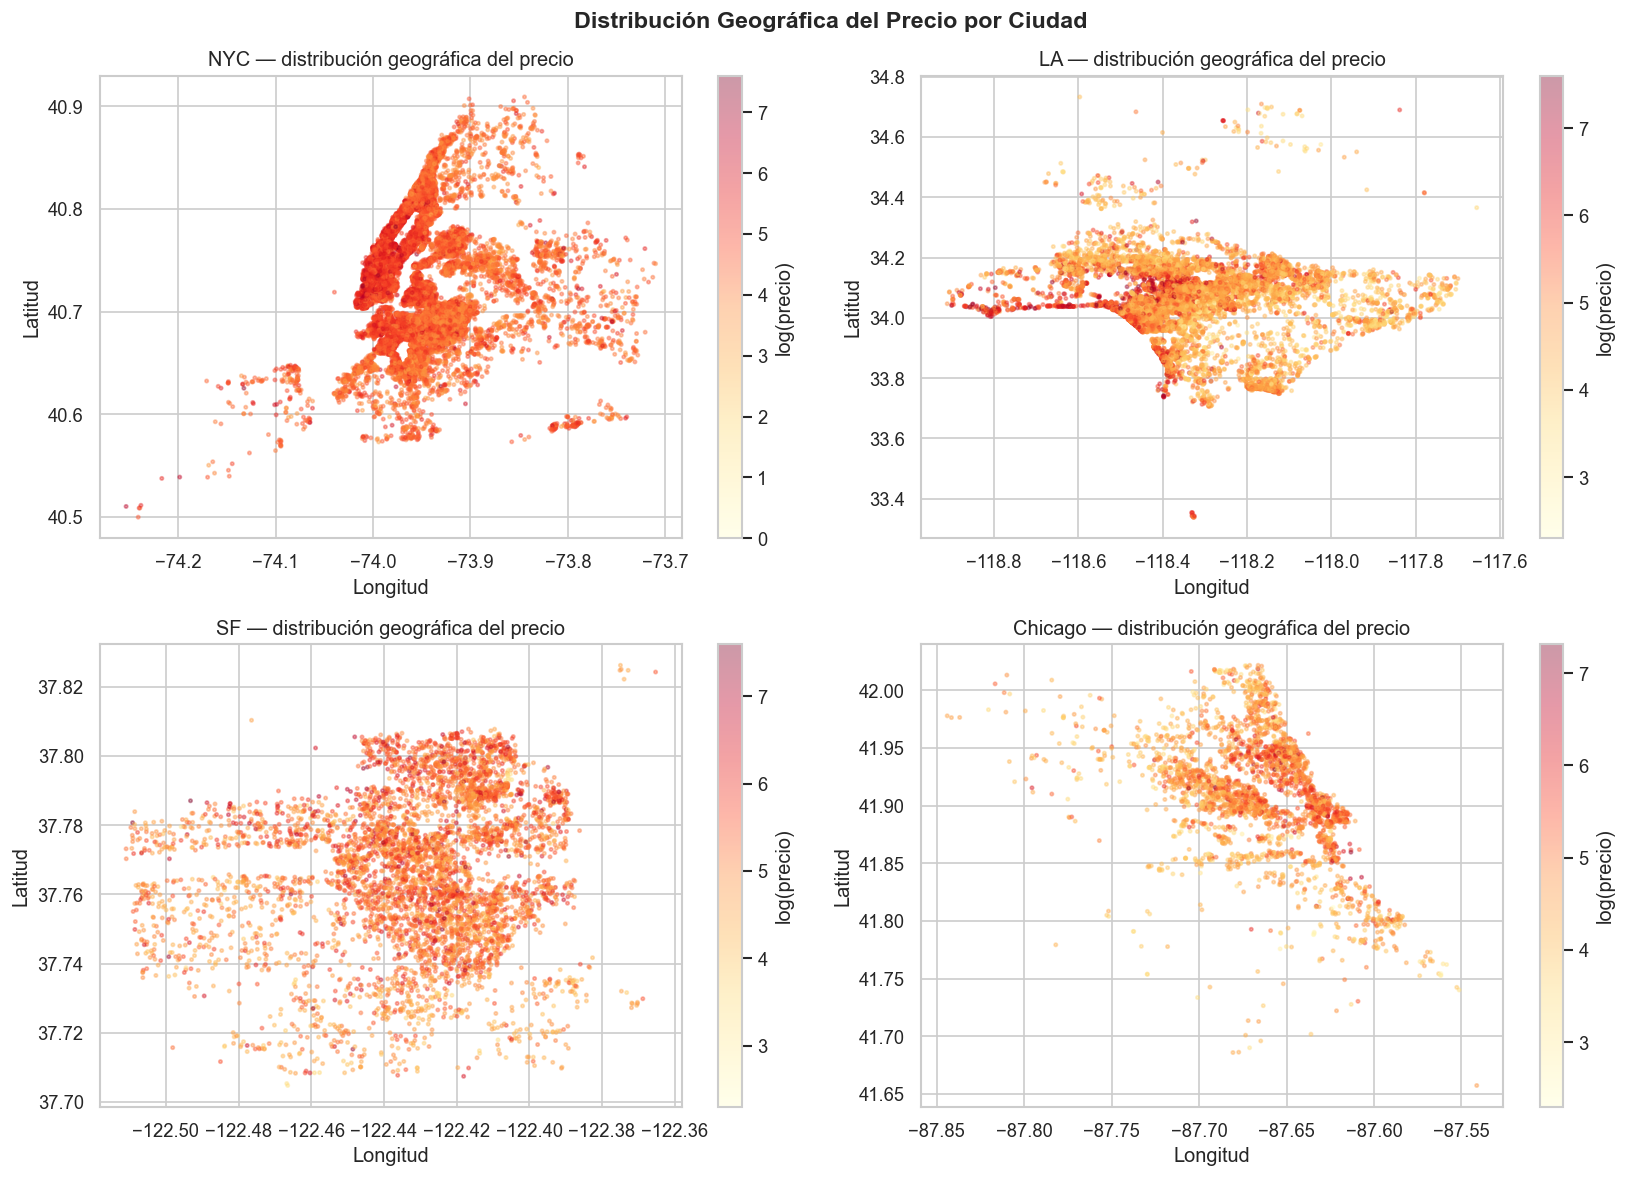

In [13]:
geo = df[['latitude', 'longitude', 'log_price', 'city']].dropna()

# Graficar por ciudad para evitar mezclar coordenadas
cities_plot = ['NYC', 'LA', 'SF', 'Chicago']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, city in enumerate(cities_plot):
    city_data = geo[geo['city'] == city]
    sc = axes[i].scatter(
        city_data['longitude'], city_data['latitude'],
        c=city_data['log_price'], cmap='YlOrRd',
        alpha=0.4, s=4
    )
    plt.colorbar(sc, ax=axes[i], label='log(precio)')
    axes[i].set_title(f'{city} — distribución geográfica del precio')
    axes[i].set_xlabel('Longitud')
    axes[i].set_ylabel('Latitud')

plt.suptitle('Distribución Geográfica del Precio por Ciudad', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 2.12 Resumen: Variables con mayor influencia en el precio

Con base en el análisis anterior, resumimos las variables con mayor poder explicativo sobre el precio.

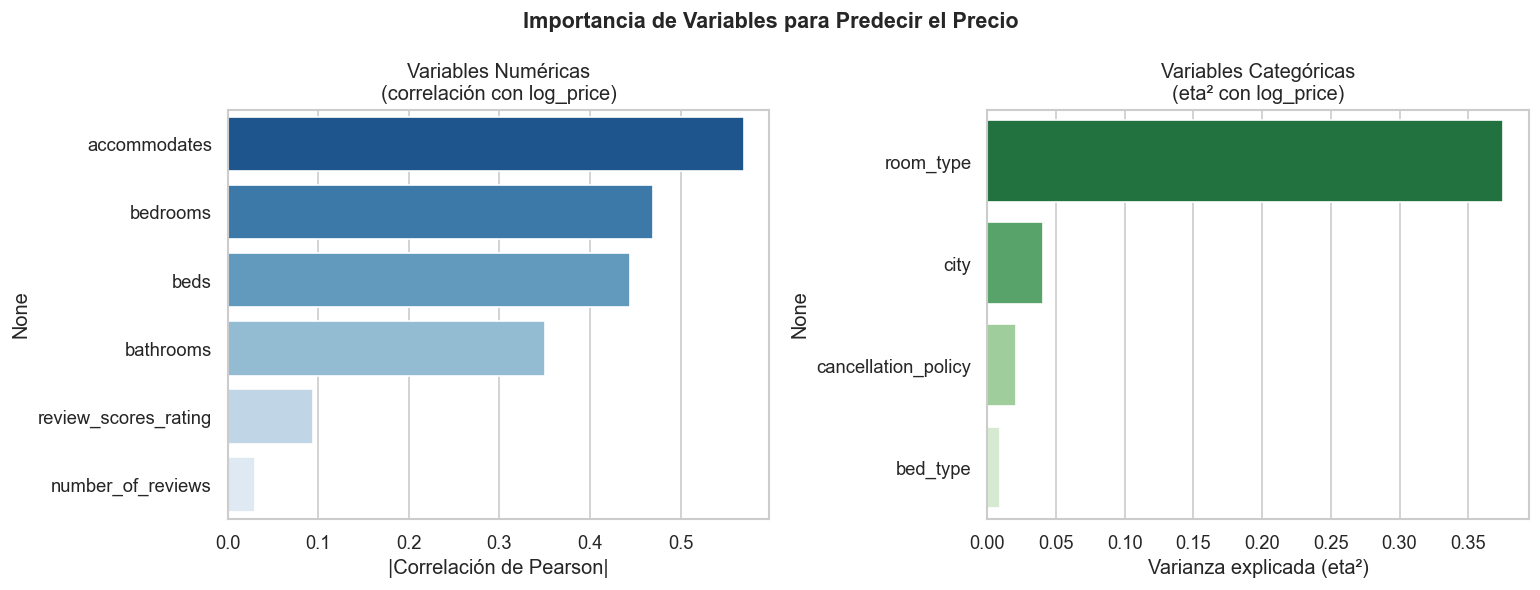

Variables numéricas (correlación):
accommodates            0.570
bedrooms                0.469
beds                    0.444
bathrooms               0.351
review_scores_rating    0.094
number_of_reviews       0.030
Name: log_price, dtype: float64

Variables categóricas (eta²):
room_type              0.375
city                   0.040
cancellation_policy    0.021
bed_type               0.010
Name: eta², dtype: float64


In [14]:
# Correlaciones numéricas
num_corr = df[corr_cols].corr()['log_price'].drop('log_price').abs().sort_values(ascending=False)

# Correlación con variables categóricas usando eta cuadrado (varianza explicada)
from scipy import stats

def eta_squared(cat_col, target='log_price'):
    groups = [group[target].dropna().values for name, group in df.groupby(cat_col)]
    f, p = stats.f_oneway(*groups)
    grand_mean = df[target].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = ((df[target] - grand_mean)**2).sum()
    return ss_between / ss_total

cat_vars = ['room_type', 'city', 'cancellation_policy', 'bed_type']
cat_eta = pd.Series({v: eta_squared(v) for v in cat_vars}, name='eta²').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x=num_corr.values, y=num_corr.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Variables Numéricas\n(correlación con log_price)')
axes[0].set_xlabel('|Correlación de Pearson|')

sns.barplot(x=cat_eta.values, y=cat_eta.index, ax=axes[1], palette='Greens_r')
axes[1].set_title('Variables Categóricas\n(eta² con log_price)')
axes[1].set_xlabel('Varianza explicada (eta²)')

plt.suptitle('Importancia de Variables para Predecir el Precio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Variables numéricas (correlación):')
print(num_corr.round(3))
print('\nVariables categóricas (eta²):')
print(cat_eta.round(3))

---
## Conclusiones del EDA

### Variables numéricas (correlación con log_price)

| Variable | Correlación | Interpretación |
|---|---|---|
| `accommodates` | 0.57 | La más fuerte — más capacidad = precio significativamente mayor |
| `bedrooms` | 0.47 | Relación positiva clara y consistente entre ciudades |
| `beds` | 0.44 | Muy correlacionada con bedrooms, información parcialmente redundante |
| `bathrooms` | 0.35 | Correlación moderada — baños adicionales suman valor |
| `review_scores_rating` | 0.09 | Prácticamente sin relación — calidad percibida no determina precio |
| `number_of_reviews` | -0.03 | Sin relación lineal con el precio |

### Variables categóricas (varianza explicada eta²)

| Variable | eta² | Interpretación |
|---|---|---|
| `room_type` | ~0.37 | **Por lejos la más importante** — explica ~37% de la varianza del precio |
| `city` | ~0.04 | Efecto moderado — SF cobra ~67% más que Chicago |
| `cancellation_policy` | ~0.02 | Políticas super_strict_60 asociadas a propiedades de lujo |
| `bed_type` | ~0.01 | Impacto mínimo |

### Patrones clave observados

**1. room_type domina todo**
Entire home/apt (55.5%) tiene una mediana visiblemente más alta que Private room (41.5%) y Shared room (2.9%). La diferencia es de aproximadamente 1 unidad en log_price, lo que equivale a ~2.7x el precio.

**2. Precio por ciudad — orden real de tus datos**
SF ($165) > Boston ($139) > DC ($125) > NYC ($105) > LA ($100) > Chicago ($99). SF es ~67% más caro que Chicago.

**3. Escala de habitaciones es clara y consistente**
De 0 a 6 habitaciones el precio sube de forma casi monotónica. Propiedades de 6 habitaciones tienen una mediana de log_price ~6.6 vs ~4.6 para 1 habitación — aproximadamente 7x el precio en dólares.

**4. Políticas de cancelación revelan segmento premium**
super_strict_60 tiene mediana log_price ~6.8 (~$900/noche), muy por encima de flexible (~4.6, ~$100/noche). No es que la política cause el precio alto — ambas son características de propiedades de lujo.

**5. Calificación y reseñas no predicen precio**
review_scores_rating está concentrado entre 80-100 en casi todos los listings, con correlación de solo 0.09. El mercado de Airbnb no premia consistentemente mejores calificaciones con precios más altos.

**6. Geografía muestra concentración por zonas**
En NYC los precios más altos (rosa oscuro) se concentran en Manhattan centro. En LA en la franja costera (Santa Monica/Venice). En SF en el norte de la ciudad. Esto sugiere que **latitud y longitud podrían ser features útiles** en el modelo.

**7. price tiene skewness de 4.29 — usar siempre log_price**
Media ($160) muy superior a mediana ($110), confirmando sesgo extremo. El modelo debe predecir log_price y convertir al final.

---
**Variables más prometedoras para el modelo:** `accommodates`, `room_type`, `bedrooms`, `bathrooms`, `city` — y posiblemente `latitude`/`longitude` para capturar el efecto de ubicación específica dentro de cada ciudad.